In [6]:
!pip install opendatasets --upgrade --quiet

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
import joblib

# PRE PROCESSAMENTO DA BASE DE DADOS
Tratamento de valores que não são ideias para aprendizado de máquina, como dias de semana, para dados legíveis.

*   Meses e horas -> Timestamp
*   On/off & Yes/No -> One Hot Coding

etc....




Skipping, found downloaded files in "./energy-consumption-prediction" (use force=True to force download)
✅ Arquivo carregado! Shape: (1000, 11)
             Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1  2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2  2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3  2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4  2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1        On            On        21.831384   Saturday      No   
2       Off           Off         6.764672     Sunday      No   
3       Off            On         8.623447  Wednesday      No   
4        On           Off         3.071969     Friday      No   

   Energ

In [ ]:

input_file = '../data/Energy_consumption.csv'
output_file = '../data/Energy_consumption_processed.csv'
df = pd.read_csv(input_file)
print(f"✅ Arquivo carregado! Shape: {df.shape}")
print(df.head())

if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(by='Timestamp')

mapeamento_binario = {
    'On': 1, 'Off': 0,
    'Yes': 1, 'No': 0
}

colunas_binarias = ['HVACUsage', 'LightingUsage', 'Holiday']

print("-> Convertendo colunas binárias...")
for col in colunas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapeamento_binario).fillna(0).astype(int)


if 'DayOfWeek' in df.columns:
    df = pd.get_dummies(df, columns=['DayOfWeek'], prefix='Day')


cols_to_scale = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']

cols_existentes = [c for c in cols_to_scale if c in df.columns]

if cols_existentes:
    print("-> Padronizando variáveis numéricas...")
    scaler = StandardScaler()
    df[cols_existentes] = scaler.fit_transform(df[cols_existentes])

if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

cols_finais = [c for c in df.columns if c != 'EnergyConsumption'] + ['EnergyConsumption']
df = df[cols_finais]

joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Pré-processamento concluído! Shape final: {df.shape}")


df.to_csv(output_file, index=False)
print(f"\nArquivo salvo: {output_file}")

import pandas as pd
from sklearn.model_selection import train_test_split

resultados_finais = []
df = pd.read_csv('../data/Energy_consumption_processed.csv')

X = df.drop(columns=['EnergyConsumption'])
y = df['EnergyConsumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_unscaled = X_train
X_test_unscaled = X_test

print(f"Treino: {X_train_unscaled.shape}")
print(f"Teste:  {X_test_unscaled.shape}")
joblib.dump(scaler, 'scaler.pkl')


-> Convertendo colunas binárias...
-> Padronizando variáveis numéricas...


In [ ]:
print("\nAmostra dos dados processados:")
display(df.head())
print(df.info())


Amostra dos dados processados:


,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,EnergyConsumption
0,0.055514,-0.230642,0.227705,0.146290,1,0,-1.413722,0,False,True,False,False,False,False,False,75.364373
1,0.969738,1.037096,-0.308690,-1.250277,1,1,0.766292,0,False,False,True,False,False,False,False,83.401855
2,1.312764,1.586942,0.886871,-0.901135,0,0,-0.957284,0,False,False,False,True,False,False,False,78.270888
3,-1.728681,0.584431,-0.165593,-1.250277,0,1,-0.744647,0,False,False,False,False,False,False,True,56.519850
4,-0.664684,0.705374,-1.408109,1.542858,1,0,-1.379716,0,True,False,False,False,False,False,False,70.811732


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        1000 non-null   float64
 1   Humidity           1000 non-null   float64
 2   SquareFootage      1000 non-null   float64
 3   Occupancy          1000 non-null   float64
 4   HVACUsage          1000 non-null   int64  
 5   LightingUsage      1000 non-null   int64  
 6   RenewableEnergy    1000 non-null   float64
 7   Holiday            1000 non-null   int64  
 8   Day_Friday         1000 non-null   bool   
 9   Day_Monday         1000 non-null   bool   
 10  Day_Saturday       1000 non-null   bool   
 11  Day_Sunday         1000 non-null   bool   
 12  Day_Thursday       1000 non-null   bool   
 13  Day_Tuesday        1000 non-null   bool   
 14  Day_Wednesday      1000 non-null   bool   
 15  EnergyConsumption  1000 non-null   float64
dtypes: bool(7), float64(6), i

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

print("-> Treinando o modelo de Regressão Linear...")
model = LinearRegression()

model.fit(X_train_unscaled, y_train)
print("✅ Treinamento concluído!")

y_pred = model.predict(X_test_unscaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n### Avaliação do Modelo ###")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinação (R-quadrado): {r2:.4f}")

model_output_file = 'linear_regression_model.pkl'
joblib.dump(model, model_output_file)
print(f"\n✅ Modelo de Regressão Linear salvo em: {model_output_file}")

resultados_finais.append({
    'Modelo': 'Regressão Linear',
    'MSE': mse,
    'R2': r2
})


Arquivo salvo: Energy_consumption_processed.csv


In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

try:
    scaler = joblib.load('scaler.pkl')
    model = joblib.load('linear_regression_model.pkl')
    print("✅ Modelo e Scaler carregados com sucesso!")
except FileNotFoundError:
    print("ERRO: Certifique-se de que 'scaler.pkl' e 'linear_regression_model.pkl' foram salvos na etapa anterior.")
    exit()

dados_brutos = {
    'Timestamp': ['2022-01-01 00:00:00'],
    'Temperature': [27.1394334377269],
    'Humidity': [43.43158120480281],
    'SquareFootage': [1296.6939992511175],
    'Occupancy': [8],
    'HVACUsage': ['On'],
    'LightingUsage': ['Off'],
    'RenewableEnergy': [16.9],
    'DayOfWeek': ['Monday'],
    'Holiday': ['No'],
    'EnergyConsumption': [91.84340824868657]
}

df_novo = pd.DataFrame(dados_brutos)
y_real = df_novo['EnergyConsumption'].iloc[0]

def preprocess_single_data(df, scaler, model_columns):
    df_proc = df.copy()

    mapeamento_binario = {'On': 1, 'Off': 0, 'Yes': 1, 'No': 0}
    colunas_binarias = ['HVACUsage', 'LightingUsage', 'Holiday']
    for col in colunas_binarias:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].map(mapeamento_binario).fillna(0).astype(int)

    if 'DayOfWeek' in df_proc.columns:
        df_proc = pd.get_dummies(df_proc, columns=['DayOfWeek'], prefix='Day')

    X_pred = pd.DataFrame(0, index=df_proc.index, columns=model_columns)
    for col in X_pred.columns:
        if col in df_proc.columns:
            X_pred[col] = df_proc[col]

    cols_to_scale = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']
    cols_existentes = [c for c in cols_to_scale if c in X_pred.columns]
    if cols_existentes:
        X_pred[cols_existentes] = scaler.transform(X_pred[cols_existentes])

    if 'Timestamp' in X_pred.columns:
        X_pred = X_pred.drop(columns=['Timestamp'], errors='ignore')
    if 'EnergyConsumption' in X_pred.columns:
        X_pred = X_pred.drop(columns=['EnergyConsumption'], errors='ignore')

    return X_pred

try:
    df_processed_train = pd.read_csv('../data/Energy_consumption_processed.csv')
    model_columns = list(df_processed_train.drop(columns=['EnergyConsumption']).columns)
except FileNotFoundError:
    print("ERRO: O arquivo 'Energy_consumption_processed.csv' não foi encontrado. Usando colunas estimadas.")
    model_columns = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy', 'HVACUsage', 'LightingUsage', 'Holiday', 'Day_Monday', 'Day_Tuesday', 'Day_Wednesday', 'Day_Thursday', 'Day_Friday', 'Day_Saturday', 'Day_Sunday']


X_pred_processed = preprocess_single_data(df_novo, scaler, model_columns)

y_pred = model.predict(X_pred_processed)

print("\n--- Resultado da Previsão ---")
print(f"Valor Real (EnergyConsumption): {y_real:.4f}")
print(f"Valor Previsto pelo Modelo:    {y_pred[0]:.4f}")
print(f"Diferença Absoluta:            {abs(y_real - y_pred[0]):.4f}")

## KNN


Dados preparados.
Treino: (800, 15)
Teste:  (200, 15)


--- Otimizando KNN com Validação Cruzada ---
K     | Média R² (CV)  
------------------------------
1     | -0.0905
2     | 0.2352
3     | 0.3127
4     | 0.3480
5     | 0.3611
6     | 0.3734
7     | 0.3906
8     | 0.3947
9     | 0.3933
10    | 0.3867
11    | 0.3882
12    | 0.3845
13    | 0.3843
14    | 0.3822
15    | 0.3754
16    | 0.3758
9     | 0.3933
10    | 0.3867
11    | 0.3882
12    | 0.3845
13    | 0.3843
14    | 0.3822
15    | 0.3754
16    | 0.3758
17    | 0.3752
18    | 0.3706
19    | 0.3680
20    | 0.3690
------------------------------
🏆 O MELHOR K (no Treino) foi: 8 (Média R²: 0.3947)

--- Resultado Final no Teste ---
R² Real: 0.4639
RMSE Real: 5.9258
17    | 0.3752
18    | 0.3706
19    | 0.3680
20    | 0.3690
------------------------------
🏆 O MELHOR K (no Treino) foi: 8 (Média R²: 0.3947)

--- Resultado Final no Teste ---
R² Real: 0.4639
RMSE Real: 5.9258


--- Otimizando KNN com Validação Cruzada ---
K     | Média R² (CV)  
------------------------------
1     | -0.0905
2     | 0.2352
3     | 0.3127
4     | 0.3480
5     | 0.3611
6     | 0.3734
7     | 0.3906
8     | 0.3947
9     | 0.3933
10    | 0.3867
11    | 0.3882
12    | 0.3845
13    | 0.3843
14    | 0.3822
15    | 0.3754
16    | 0.3758
9     | 0.3933
10    | 0.3867
11    | 0.3882
12    | 0.3845
13    | 0.3843
14    | 0.3822
15    | 0.3754
16    | 0.3758
17    | 0.3752
18    | 0.3706
19    | 0.3680
20    | 0.3690
------------------------------
🏆 O MELHOR K (no Treino) foi: 8 (Média R²: 0.3947)

--- Resultado Final no Teste ---
R² Real: 0.4639
RMSE Real: 5.9258
17    | 0.3752
18    | 0.3706
19    | 0.3680
20    | 0.3690
------------------------------
🏆 O MELHOR K (no Treino) foi: 8 (Média R²: 0.3947)

--- Resultado Final no Teste ---
R² Real: 0.4639
RMSE Real: 5.9258


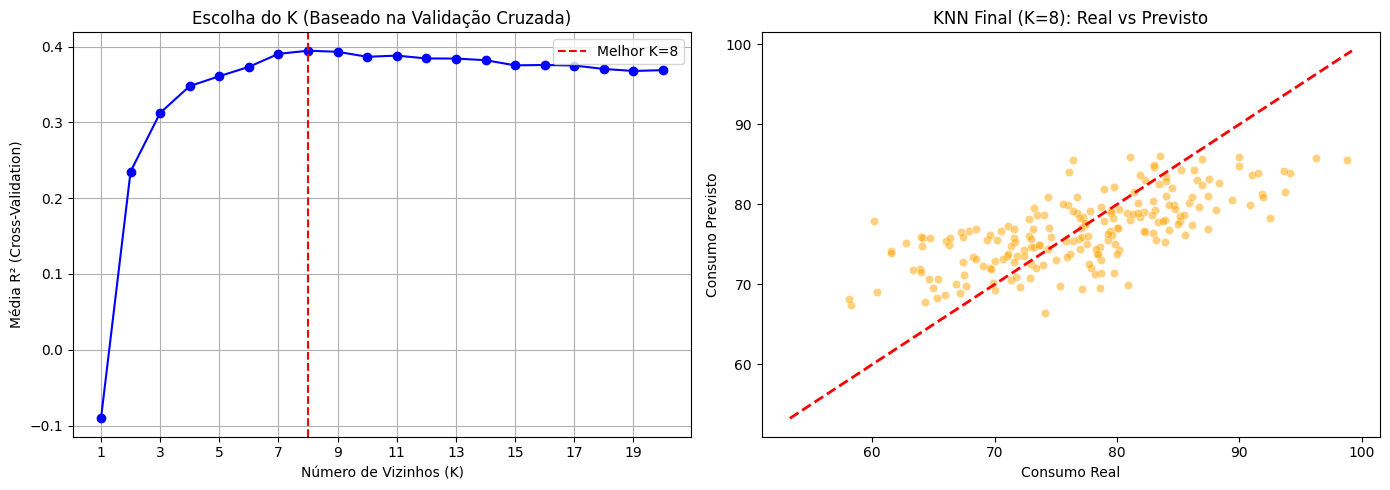

In [10]:
print("--- Otimizando KNN com Validação Cruzada ---")

# Listas para armazenar o histórico
k_values = []
cv_scores = [] # Scores da validação cruzada (Média)

best_k = 0
best_cv_score = -np.inf

print(f"{'K':<5} | {'Média R² (CV)':<15}")
print("-" * 30)

# 1. Loop de Otimização (Usando APENAS dados de treino)
for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)

    # O modelo é testado 5x dentro do próprio treino
    # cv=5 divide o treino em 5 partes. Treina em 4, valida em 1.
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_score = scores.mean()

    k_values.append(k)
    cv_scores.append(mean_score)

    print(f"{k:<5} | {mean_score:.4f}")

    if mean_score > best_cv_score:
        best_k = k
        best_cv_score = mean_score

print("-" * 30)
print(f"🏆 O MELHOR K (no Treino) foi: {best_k} (Média R²: {best_cv_score:.4f})")

# 2. Treinamento Final e Teste Real
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train) # Treina com TUDO do treino
y_pred = final_model.predict(X_test_scaled) # Preve no teste

# Métricas Finais
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Resultado Final no Teste ---")
print(f"R² Real: {final_r2:.4f}")
print(f"RMSE Real: {final_rmse:.4f}")

# Salva na lista de comparação
resultados_finais.append({'Modelo': f'KNN (K={best_k})', 'R2': final_r2, 'RMSE': final_rmse})

# --- GRÁFICOS ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Curva de Aprendizado (Baseada na Validação Cruzada)
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Melhor K={best_k}')
plt.title('Escolha do K (Baseado na Validação Cruzada)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Média R² (Cross-Validation)')
plt.xticks(range(1, 21, 2))
plt.legend()
plt.grid(True)

# Gráfico 2: Real vs Previsto (Teste Final)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"KNN Final (K={best_k}): Real vs Previsto")
plt.xlabel("Consumo Real")
plt.ylabel("Consumo Previsto")

plt.tight_layout()
plt.show()

## MACHINE LAYER PERCEPTRON (MLP)


In [16]:
import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings("ignore")


def objective(trial):

    # ============================
    # ARQUITETURA DINÂMICA
    # ============================
    n_layers = trial.suggest_int("n_layers", 1, 3)

    hidden_layers = []
    for i in range(n_layers):
        neurons = trial.suggest_int(f"n_neurons_layer_{i}", 10, 200)
        hidden_layers.append(neurons)
    hidden_layers = tuple(hidden_layers)

    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd", "lbfgs"])

    # ============================
    # HIPERPARÂMETROS
    # ============================

    # Learning rate limitado para estabilidade
    if solver == "sgd":
        learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 2e-3, log=True)
        momentum = trial.suggest_float("momentum", 0.1, 0.95)
        max_iter = trial.suggest_int("max_iter", 300, 1200)
    else:  # adam e lbfgs podem ir mais alto
        learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
        momentum = 0.9
        max_iter = trial.suggest_int("max_iter", 500, 3000)

    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)

    model = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        momentum=momentum,
        random_state=42
    )

    # ============================
    # TREINO COM TRY/CATCH
    # ============================
    try:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)

        # ignora resultados absurdos da rede ainda instável
        if not np.isfinite(r2):
            raise ValueError("R² inválido")

        return r2

    except Exception:
        return -999  # valor ruim que elimina a combinação


# ============================
# EXECUTANDO O ESTUDO
# ============================

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print("Melhores hiperparâmetros:")
print(study.best_params)

best_params = study.best_params

# Recriando o melhor modelo
best_model = MLPRegressor(
    hidden_layer_sizes=tuple(best_params[f"n_neurons_layer_{i}"] for i in range(best_params["n_layers"])),
    activation=best_params["activation"],
    solver=best_params["solver"],
    alpha=best_params["alpha"],
    learning_rate_init=best_params["learning_rate_init"],
    max_iter=best_params["max_iter"],
    momentum=best_params.get("momentum", 0.9),
    random_state=42
)

best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

best_r2 = r2_score(y_test, y_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n🏆 R² Teste Final: {best_r2:.4f}")
print(f"📉 RMSE Teste Final: {best_rmse:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: 'seu_dataset.csv'

## REGRESSÃO LINEAR

--- Avaliando Regressão Linear ---
Média R² (CV): 0.6059
Desvio Padrão: 0.0237

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1524


--- Avaliando Regressão Linear ---
Média R² (CV): 0.6059
Desvio Padrão: 0.0237

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1524


C:\Users\gushd\AppData\Local\Temp\ipykernel_416\3387775539.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=coefs, palette='coolwarm')


--- Avaliando Regressão Linear ---
Média R² (CV): 0.6059
Desvio Padrão: 0.0237

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1524


C:\Users\gushd\AppData\Local\Temp\ipykernel_416\3387775539.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=coefs, palette='coolwarm')


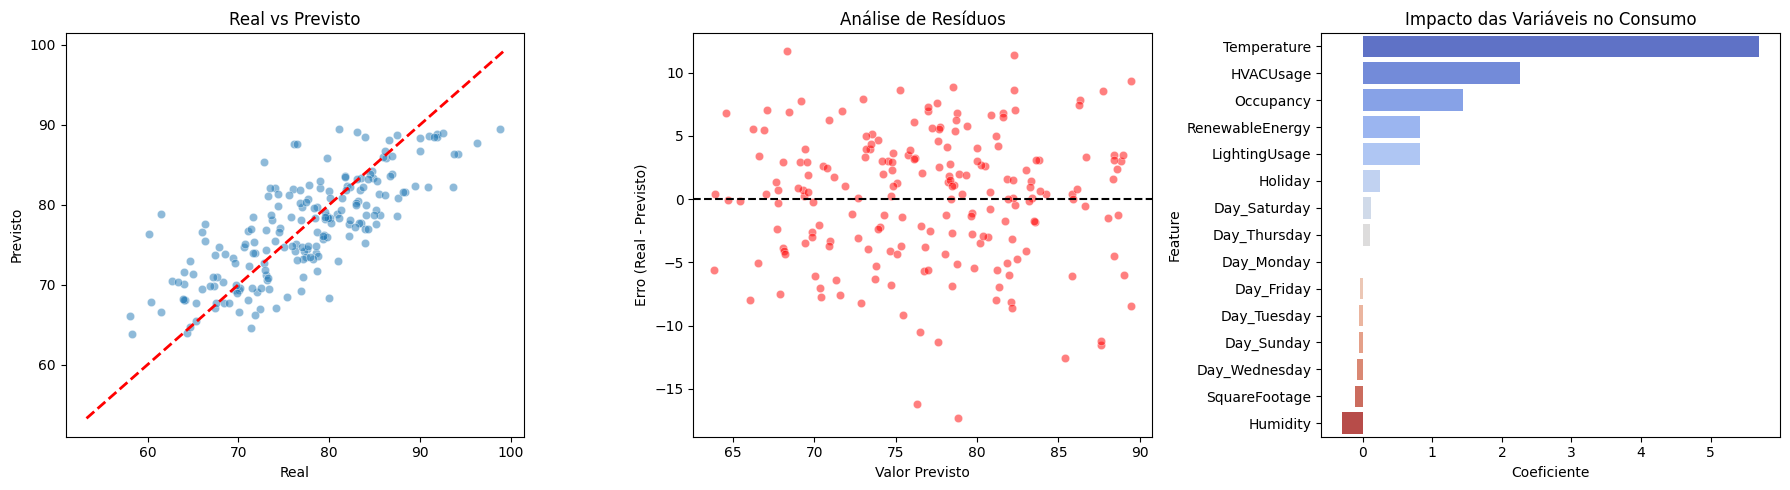

In [12]:
import joblib

print("--- Avaliando Regressão Linear ---")

# 1. Validação Cruzada (Checando a estabilidade)
model_lr = LinearRegression()
cv_scores = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Média R² (CV): {cv_scores.mean():.4f}")
print(f"Desvio Padrão: {cv_scores.std():.4f}")

# 2. Treinamento Final
model_lr.fit(X_train_scaled, y_train)

# 3. Previsão no Teste
y_pred_lr = model_lr.predict(X_test_scaled)

# 4. Métricas Finais
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"\n--- Resultado Final (Teste) ---")
print(f"R² Score: {r2_lr:.4f}")
print(f"RMSE:     {rmse_lr:.4f}")

resultados_finais.append({'Modelo': 'Regressão Linear', 'R2': r2_lr, 'RMSE': rmse_lr})

joblib.dump(model_lr, 'linear_regression_model.pkl')
print("Modelo de Regressão Linear salvo como 'linear_regression_model.pkl'") 
joblib.dump(scaler, 'standard_scaler.pkl')
print("Scaler salvo como 'standard_scaler.pkl'")

## RANDOM FOREST

--- Otimizando Random Forest com Validação Cruzada ---
Árvores  | Média R² (CV)  
------------------------------
10       | 0.5113
50       | 0.5417
50       | 0.5417
100      | 0.5474
100      | 0.5474
150      | 0.5499
150      | 0.5499
200      | 0.5507
200      | 0.5507
300      | 0.5518
300      | 0.5518
400      | 0.5512
400      | 0.5512
500      | 0.5508
500      | 0.5508
600      | 0.5515
600      | 0.5515
700      | 0.5515
700      | 0.5515
800      | 0.5521
800      | 0.5521
900      | 0.5526
900      | 0.5526
1000     | 0.5532
------------------------------
🏆 MELHOR Configuração (no Treino): 1000 árvores (Média R²: 0.5532)

Treinando modelo final com 1000 árvores...
1000     | 0.5532
------------------------------
🏆 MELHOR Configuração (no Treino): 1000 árvores (Média R²: 0.5532)

Treinando modelo final com 1000 árvores...
R² Final (no Teste): 0.5492
RMSE Final: 5.4341
R² Final (no Teste): 0.5492
RMSE Final: 5.4341


--- Otimizando Random Forest com Validação Cruzada ---
Árvores  | Média R² (CV)  
------------------------------
10       | 0.5113
50       | 0.5417
50       | 0.5417
100      | 0.5474
100      | 0.5474
150      | 0.5499
150      | 0.5499
200      | 0.5507
200      | 0.5507
300      | 0.5518
300      | 0.5518
400      | 0.5512
400      | 0.5512
500      | 0.5508
500      | 0.5508
600      | 0.5515
600      | 0.5515
700      | 0.5515
700      | 0.5515
800      | 0.5521
800      | 0.5521
900      | 0.5526
900      | 0.5526
1000     | 0.5532
------------------------------
🏆 MELHOR Configuração (no Treino): 1000 árvores (Média R²: 0.5532)

Treinando modelo final com 1000 árvores...
1000     | 0.5532
------------------------------
🏆 MELHOR Configuração (no Treino): 1000 árvores (Média R²: 0.5532)

Treinando modelo final com 1000 árvores...
R² Final (no Teste): 0.5492
RMSE Final: 5.4341
R² Final (no Teste): 0.5492
RMSE Final: 5.4341


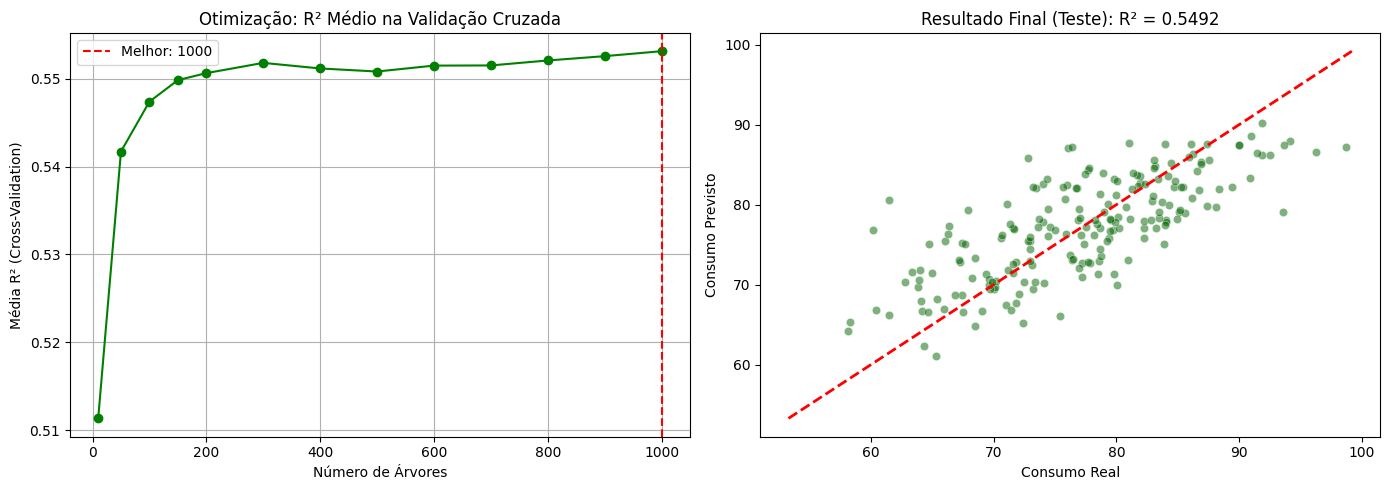

In [13]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Otimizando Random Forest com Optuna e Validação Cruzada ---")


def objective(trial):

    # Hiperparâmetros a otimizar
    n_estimators = trial.suggest_int("n_estimators", 50, 1200)
    max_depth = trial.suggest_int("max_depth", 3, 40)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("===========================================")
print("🏆 Melhor R² Médio (CV):", study.best_value)
print("Melhores parâmetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


# ============================================================
# TREINAMENTO FINAL COM OS MELHORES PARÂMETROS
# ============================================================

best_params = study.best_params

final_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_final = final_model.predict(X_test_scaled)

final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("\n=== RESULTADOS NO TESTE ===")
print(f"R² Final          : {final_r2:.4f}")
print(f"RMSE Final        : {final_rmse:.4f}")


# ============================================================
# GRÁFICOS
# ============================================================

plt.figure(figsize=(14, 5))

# Gráfico 1: Importâncias (opcional, mas útil)
plt.subplot(1, 2, 1)
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(range(len(importances)), importances[indices])
plt.title("Importância das Features (Random Forest)")
plt.xlabel("Features (ordenadas)")
plt.ylabel("Importância")

# Gráfico 2: Real vs Previsto
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Resultado Final (Teste): R² = {final_r2:.4f}")
plt.xlabel("Real")
plt.ylabel("Previsto")

plt.tight_layout()
plt.show()

# Salvando no seu dicionário de resultados
resultados_finais.append({
    "Modelo": "Random Forest (Optuna)",
    "R2": final_r2,
    "RMSE": final_rmse
})


## NAIVE BAYES


--- Avaliando Regressão Bayesiana (Substituto do Naive Bayes) ---
Média R² (CV): 0.6061
Desvio Padrão: 0.0225

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1526


--- Avaliando Regressão Bayesiana (Substituto do Naive Bayes) ---
Média R² (CV): 0.6061
Desvio Padrão: 0.0225

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1526


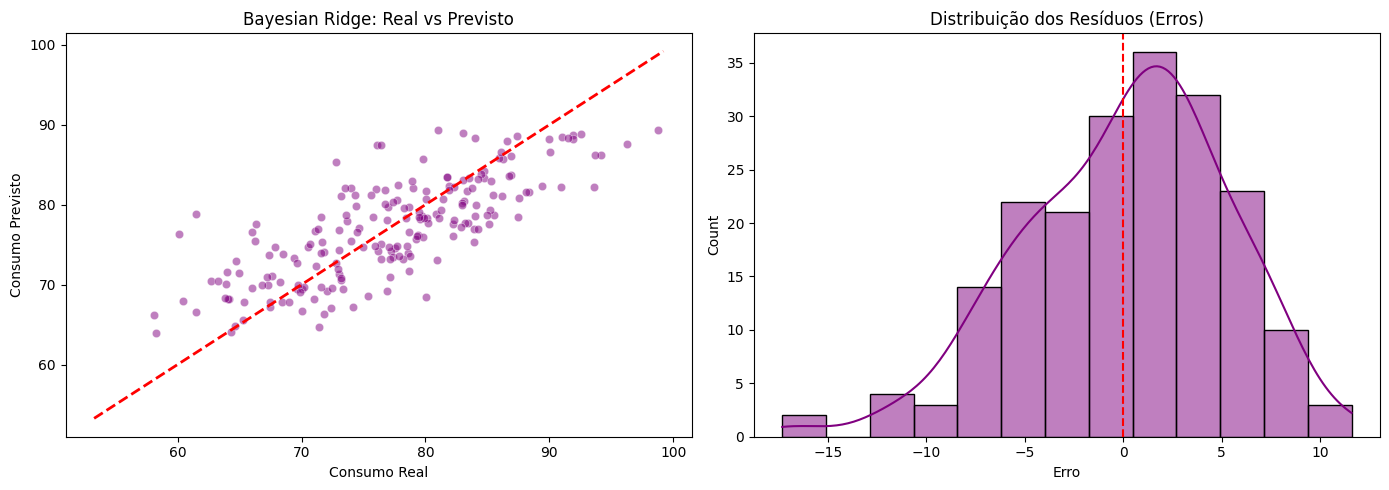

In [14]:
print("--- Avaliando Regressão Bayesiana (Substituto do Naive Bayes) ---")

# 1. Instanciar o Modelo
model_bayes = BayesianRidge()

# 2. Validação Cruzada (Cross-Validation)
cv_scores = cross_val_score(model_bayes, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Média R² (CV): {cv_scores.mean():.4f}")
print(f"Desvio Padrão: {cv_scores.std():.4f}")

model_bayes.fit(X_train_scaled, y_train)

y_pred_bayes = model_bayes.predict(X_test_scaled)

r2_bayes = r2_score(y_test, y_pred_bayes)
rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))

print(f"\n--- Resultado Final (Teste) ---")
print(f"R² Score: {r2_bayes:.4f}")
print(f"RMSE:     {rmse_bayes:.4f}")

resultados_finais.append({'Modelo': 'Bayesian Ridge', 'R2': r2_bayes, 'RMSE': rmse_bayes})

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_bayes, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Bayesian Ridge: Real vs Previsto")
plt.xlabel("Consumo Real")
plt.ylabel("Consumo Previsto")

residuos = y_test - y_pred_bayes
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='r', linestyle='--')
plt.title("Distribuição dos Resíduos (Erros)")
plt.xlabel("Erro")

plt.tight_layout()
plt.show()

### Salvando o melhor modelo

In [15]:
joblib.dump(model_lr, "ecoagent_linear_model.pkl")
joblib.dump(scaler, "ecoagent_scaler.pkl")

['ecoagent_scaler.pkl']